# 🌫️ Notebook 1 — Ingestion & Partitioning
### Team 8 · Delhi Air Quality Pipeline
**Member: Nelson**

---

## What this notebook does
This is the **first stage** of the pipeline:
1. Set up PySpark on Kaggle
2. Load the raw parquet file (`team_8.parquet`)
3. Run a **data-quality report** — null counts and value ranges
4. Explore the dataset — distributions, date range, stations, pollutants
5. **Visualise** key statistics inline
6. Partition the data into year/month folders
7. Save an ingestion summary for the team

The output (`partitioned_data/`) is what Member 2 uses as input.

> **What's new vs the original notebook**  
>  Kaggle-native data loading (no manual upload needed)  
>  Data-quality report with null counts before any processing  
>  Value-range check per pollutant (min/max/mean)  
>  4 inline visualisations (readings/year, readings/pollutant, station heatmap, null heatmap)  
>  Partition verification with row-count cross-check  
>  Structured summary saved as text file

## Step 1 · Environment Setup

In [1]:
!apt-get install -y openjdk-17-jdk-headless -qq > /dev/null
!pip install pyspark -q

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
print("Java ready")

Java ready


## Step 2 · Load the Dataset
We use `kagglehub` to download the dataset directly — no manual upload needed on Kaggle.

In [2]:
import kagglehub

path = kagglehub.dataset_download("nelsonnoelzakayo/group-8")
print("Dataset path:", path)

Dataset path: /kaggle/input/datasets/nelsonnoelzakayo/group-8


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("Team8_Ingestion")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
print(" Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/03 16:58:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


 Spark version: 4.0.2


In [4]:
# Load the parquet file — Spark reads lazily (no data in memory yet)
PARQUET_PATH = "/kaggle/input/datasets/nelsonnoelzakayo/group-8/team_8.parquet"

df = spark.read.parquet(PARQUET_PATH)
print("Schema:")
df.printSchema()

Schema:
root
 |-- station_id: string (nullable = true)
 |-- state: string (nullable = true)
 |-- city: string (nullable = true)
 |-- station_name: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- at_c: double (nullable = true)
 |-- rh_percent: double (nullable = true)
 |-- ws_m_s: double (nullable = true)
 |-- wd_deg: double (nullable = true)
 |-- rf_mm: double (nullable = true)
 |-- tot_rf_mm: double (nullable = true)
 |-- sr_w_mt2: double (nullable = true)
 |-- bp_mmhg: double (nullable = true)
 |-- vws_m_s: double (nullable = true)
 |-- pollutant: string (nullable = true)
 |-- value: double (nullable = true)
 |-- station: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)



In [5]:
# count() is the first action — Spark actually reads the file here
total_rows = df.count()
col_count  = len(df.columns)
print(f" Loaded {total_rows:,} rows across {col_count} columns")

 Loaded 22,476,854 rows across 22 columns


In [6]:
# Peek at the first 5 rows
df.show(5, truncate=False)

+----------+-----+-----+----------------------+-------------------------------+-------------------+----+----------+------+------+-----+---------+--------+-------+-------+-----------+-----+----------------------+----+-----+---+----+
|station_id|state|city |station_name          |timestamp                      |datetime           |at_c|rh_percent|ws_m_s|wd_deg|rf_mm|tot_rf_mm|sr_w_mt2|bp_mmhg|vws_m_s|pollutant  |value|station               |year|month|day|hour|
+----------+-----+-----+----------------------+-------------------------------+-------------------+----+----------+------+------+-----+---------+--------+-------+-------+-----------+-----+----------------------+----+-----+---+----+
|site_5024 |Delhi|Delhi|Alipur, Delhi - DPCC  |2024-01-01T00:00:00.000000+0000|2024-01-01 00:00:00|8.2 |76.0      |NULL  |72.9  |0.0  |0.0      |3.8     |973.7  |NULL   |benzene    |2.1  |Alipur, Delhi - DPCC  |2024|1    |1  |0   |
|site_113  |Delhi|Delhi|Shadipur, Delhi - CPCB|2024-01-01T00:00:00.00000

## Step 3 · Data-Quality Report (NEW)
Before doing anything else, we check for missing values and suspicious value ranges.
This is essential — aggregating data with hidden nulls produces wrong results downstream.

In [7]:
import pandas as pd

# ── 3a. Null counts ──────────────────────────────────────────────────────
null_counts = df.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
).toPandas().T
null_counts.columns = ["null_count"]
null_counts["pct_missing"] = (null_counts["null_count"] / total_rows * 100).round(2)
null_counts = null_counts.sort_values("null_count", ascending=False)

print("Null counts per column:")
print(null_counts.to_string())

Null counts per column:
              null_count  pct_missing
vws_m_s         18578166        82.65
rf_mm            8670524        38.58
bp_mmhg          8352208        37.16
at_c             7249008        32.25
ws_m_s           5378876        23.93
sr_w_mt2         5293941        23.55
wd_deg           4640316        20.64
rh_percent       4020948        17.89
tot_rf_mm        2193732         9.76
timestamp              0         0.00
state                  0         0.00
station_id             0         0.00
station_name           0         0.00
city                   0         0.00
datetime               0         0.00
pollutant              0         0.00
value                  0         0.00
station                0         0.00
year                   0         0.00
month                  0         0.00
day                    0         0.00
hour                   0         0.00


In [8]:
# ── 3b. Value range per pollutant ───────────────────────────────────────
# Shows min / mean / max of the sensor reading for each pollutant.
# Extreme max values (e.g. 99999) often indicate sensor errors.
value_stats = (
    df.groupBy("pollutant")
      .agg(
          F.min("value").alias("min"),
          F.round(F.avg("value"), 2).alias("mean"),
          F.max("value").alias("max"),
          F.count("value").alias("non_null_readings"),
          F.sum(F.col("value").isNull().cast("int")).alias("null_readings")
      )
      .orderBy("pollutant")
)
print("Value ranges per pollutant:")
value_stats.show(20, truncate=False)

Value ranges per pollutant:


+-----------+----+------+------+-----------------+-------------+
|pollutant  |min |mean  |max   |non_null_readings|null_readings|
+-----------+----+------+------+-----------------+-------------+
|benzene    |0.0 |2.02  |499.9 |1880719          |0            |
|co         |0.0 |1.29  |49.97 |2309095          |0            |
|eth_benzene|0.01|2.15  |141.07|367217           |0            |
|mp_xylene  |0.01|2.16  |349.7 |379487           |0            |
|nh3        |0.01|38.37 |500.0 |1898880          |0            |
|no         |0.01|28.12 |500.0 |2328324          |0            |
|no2        |0.01|44.81 |499.4 |2405080          |0            |
|ozone      |0.01|35.14 |498.48|2320066          |0            |
|pm10       |0.01|204.15|1000.0|2408005          |0            |
|pm25       |0.01|100.69|1000.0|2371296          |0            |
|so2        |0.01|15.24 |200.0 |1873538          |0            |
|toluene    |0.0 |10.82 |495.7 |1680566          |0            |
|xylene     |0.0 |4.68  |

## Step 4 · Ingestion Summary

In [9]:
# Date range
date_range = df.agg(
    F.min("datetime").alias("min_dt"),
    F.max("datetime").alias("max_dt")
).collect()[0]

print("INGESTION SUMMARY")
print("=" * 60)
print(f"Total records : {total_rows:,}")
print(f"Columns       : {col_count}")
print(f"Date range    : {date_range['min_dt']} to {date_range['max_dt']}")
print(f"States        : {df.select('state').distinct().count()}")
print(f"Cities        : {df.select('city').distinct().count()}")
print(f"Stations      : {df.select('station_id').distinct().count()}")
print(f"Pollutants    : {df.select('pollutant').distinct().count()}")

INGESTION SUMMARY
Total records : 22,476,854
Columns       : 22
Date range    : 2024-01-01 00:00:00 to 2025-12-31 23:45:00


States        : 1


Cities        : 1


Stations      : 37


Pollutants    : 13


In [10]:
# List all pollutants (with correct lowercase names — important for Member 2)
print("Pollutants in the dataset:")
df.select("pollutant").distinct().orderBy("pollutant").show()

Pollutants in the dataset:


+-----------+
|  pollutant|
+-----------+
|    benzene|
|         co|
|eth_benzene|
|  mp_xylene|
|        nh3|
|         no|
|        no2|
|      ozone|
|       pm10|
|       pm25|
|        so2|
|    toluene|
|     xylene|
+-----------+



In [11]:
# Records per year and month
print("Records per year and month:")
df.groupBy("year", "month").count().orderBy("year", "month").show(36)

Records per year and month:


+----+-----+------+
|year|month| count|
+----+-----+------+
|2024|    1|952234|
|2024|    2|899964|
|2024|    3|957047|
|2024|    4|919426|
|2024|    5|954587|
|2024|    6|912522|
|2024|    7|956187|
|2024|    8|941088|
|2024|    9|913645|
|2024|   10|947855|
|2024|   11|947909|
|2024|   12|973284|
|2025|    1|957949|
|2025|    2|878144|
|2025|    3|974006|
|2025|    4|930159|
|2025|    5|957324|
|2025|    6|906771|
|2025|    7|923757|
|2025|    8|925611|
|2025|    9|886149|
|2025|   10|964095|
|2025|   11|941847|
|2025|   12|955294|
+----+-----+------+



In [12]:
# Records per pollutant
print("Records per pollutant:")
df.groupBy("pollutant").count().orderBy(F.desc("count")).show()

Records per pollutant:


+-----------+-------+
|  pollutant|  count|
+-----------+-------+
|       pm10|2408005|
|        no2|2405080|
|       pm25|2371296|
|         no|2328324|
|      ozone|2320066|
|         co|2309095|
|        nh3|1898880|
|    benzene|1880719|
|        so2|1873538|
|    toluene|1680566|
|  mp_xylene| 379487|
|eth_benzene| 367217|
|     xylene| 254581|
+-----------+-------+



## Step 5 · Visualisations (NEW)
Four plots generated directly from Spark — pulled into pandas for plotting.

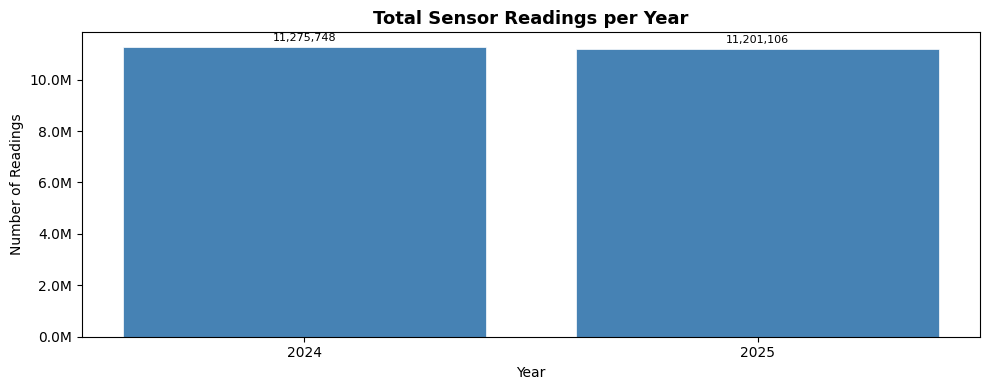

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── 5a. Readings per Year ────────────────────────────────────────────────
yearly = (
    df.groupBy("year").count()
      .orderBy("year")
      .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(yearly["year"].astype(str), yearly["count"],
              color="steelblue", edgecolor="white", linewidth=0.5)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=8)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Readings")
ax.set_title("Total Sensor Readings per Year", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("/kaggle/working/viz_readings_per_year.png", dpi=120)
plt.show()

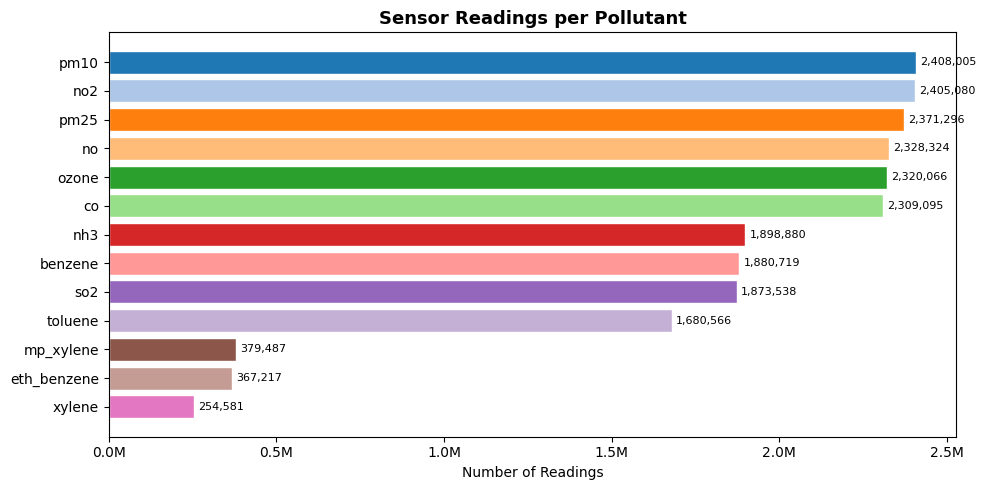

In [14]:
# ── 5b. Readings per Pollutant ──────────────────────────────────────────
poll_counts = (
    df.groupBy("pollutant").count()
      .orderBy(F.desc("count"))
      .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab20.colors[:len(poll_counts)]
bars = ax.barh(poll_counts["pollutant"][::-1], poll_counts["count"][::-1],
               color=list(colors)[::-1], edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=8)
ax.set_xlabel("Number of Readings")
ax.set_title("Sensor Readings per Pollutant", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("/kaggle/working/viz_readings_per_pollutant.png", dpi=120)
plt.show()

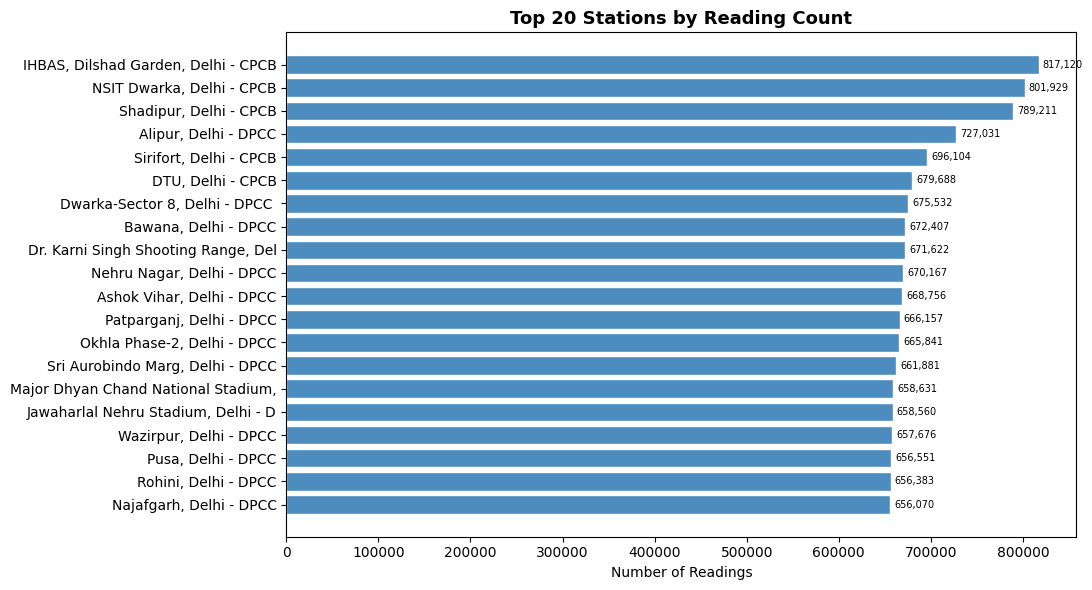

In [15]:
# ── 5c. Readings per Station (top 20) ───────────────────────────────────
station_counts = (
    df.groupBy("station_id", "station_name").count()
      .orderBy(F.desc("count"))
      .limit(20)
      .toPandas()
)
# shorten long names
station_counts["label"] = station_counts["station_name"].str[:35]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(station_counts["label"][::-1], station_counts["count"][::-1],
               color="#4c8cbf", edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=7)
ax.set_xlabel("Number of Readings")
ax.set_title("Top 20 Stations by Reading Count", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/viz_top_stations.png", dpi=120)
plt.show()

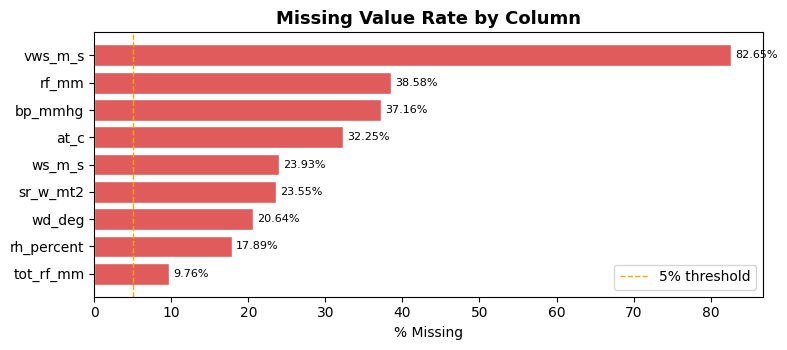

In [16]:
# ── 5d. Null heatmap — which columns have missing data ──────────────────
# Reuse null_counts from Step 3; only show columns that have at least 1 null.
null_display = null_counts[null_counts["null_count"] > 0].copy()

if null_display.empty:
    print(" No missing values — nothing to plot.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(null_display) * 0.4)))
    bars = ax.barh(null_display.index[::-1], null_display["pct_missing"][::-1],
                   color="#e05c5c", edgecolor="white")
    ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=8)
    ax.set_xlabel("% Missing")
    ax.set_title("Missing Value Rate by Column", fontsize=13, fontweight="bold")
    ax.axvline(5, color="orange", linestyle="--", linewidth=1, label="5% threshold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/viz_null_heatmap.png", dpi=120)
    plt.show()

## Step 6 · Partition the Data by Year and Month
PySpark's `partitionBy` creates Hive-style folders (`year=YYYY/month=MM/`).
This is the standard big-data pattern — queries only scan the partitions they need
instead of reading the entire file.

In [17]:
OUTPUT_PATH = "/kaggle/working/partitioned_data"

(
    df
    .write
    .mode("overwrite")
    .partitionBy("year", "month")
    .parquet(OUTPUT_PATH)
)
print(" Partitioning complete!")

 Partitioning complete!


In [18]:
# Verify the folder structure was created
import subprocess
result = subprocess.run(["find", OUTPUT_PATH, "-type", "d"],
                       capture_output=True, text=True)
folders = sorted(result.stdout.strip().split("\n"))
print(f"Created {len(folders)} partition folders. First 20:")
for f in folders[:20]:
    print(" ", f)

Created 27 partition folders. First 20:
  /kaggle/working/partitioned_data
  /kaggle/working/partitioned_data/year=2024
  /kaggle/working/partitioned_data/year=2024/month=1
  /kaggle/working/partitioned_data/year=2024/month=10
  /kaggle/working/partitioned_data/year=2024/month=11
  /kaggle/working/partitioned_data/year=2024/month=12
  /kaggle/working/partitioned_data/year=2024/month=2
  /kaggle/working/partitioned_data/year=2024/month=3
  /kaggle/working/partitioned_data/year=2024/month=4
  /kaggle/working/partitioned_data/year=2024/month=5
  /kaggle/working/partitioned_data/year=2024/month=6
  /kaggle/working/partitioned_data/year=2024/month=7
  /kaggle/working/partitioned_data/year=2024/month=8
  /kaggle/working/partitioned_data/year=2024/month=9
  /kaggle/working/partitioned_data/year=2025
  /kaggle/working/partitioned_data/year=2025/month=1
  /kaggle/working/partitioned_data/year=2025/month=10
  /kaggle/working/partitioned_data/year=2025/month=11
  /kaggle/working/partitioned_data/

In [19]:
# ── NEW: Partition row-count cross-check ────────────────────────────────
# Read the partitioned data back and confirm the row count matches the
# original. A mismatch means data was lost or duplicated during the write.
df_verify = spark.read.parquet(OUTPUT_PATH)
verify_count = df_verify.count()

print(f"Original rows : {total_rows:,}")
print(f"Partitioned   : {verify_count:,}")

if verify_count == total_rows:
    print("Row counts match — partition write is correct")
else:
    diff = verify_count - total_rows
    print(f"  MISMATCH: difference of {diff:,} rows — investigate before handing off!")

Original rows : 22,476,854
Partitioned   : 22,476,854
Row counts match — partition write is correct


In [20]:
# Check one specific partition reads back cleanly
sample = spark.read.parquet(f"{OUTPUT_PATH}/year=2024/month=1/")
print(f"Rows in Jan 2024 partition: {sample.count():,}")
sample.show(3, truncate=False)

Rows in Jan 2024 partition: 952,234
+----------+-----+-----+----------------------+-------------------------------+-------------------+----+----------+------+------+-----+---------+--------+-------+-------+-----------+-----+----------------------+---+----+
|station_id|state|city |station_name          |timestamp                      |datetime           |at_c|rh_percent|ws_m_s|wd_deg|rf_mm|tot_rf_mm|sr_w_mt2|bp_mmhg|vws_m_s|pollutant  |value|station               |day|hour|
+----------+-----+-----+----------------------+-------------------------------+-------------------+----+----------+------+------+-----+---------+--------+-------+-------+-----------+-----+----------------------+---+----+
|site_5024 |Delhi|Delhi|Alipur, Delhi - DPCC  |2024-01-01T00:00:00.000000+0000|2024-01-01 00:00:00|8.2 |76.0      |NULL  |72.9  |0.0  |0.0      |3.8     |973.7  |NULL   |benzene    |2.1  |Alipur, Delhi - DPCC  |1  |0   |
|site_113  |Delhi|Delhi|Shadipur, Delhi - CPCB|2024-01-01T00:00:00.000000+0000|2

## Step 7 · Save Ingestion Summary

In [21]:
pollutant_list = [r["pollutant"] for r in df.select("pollutant").distinct().orderBy("pollutant").collect()]

summary_text = f'''INGESTION SUMMARY — Team 8 Delhi Air Quality Pipeline
{"=" * 60}
Total records : {total_rows:,}
Columns       : {col_count}
Date range    : {date_range["min_dt"]} to {date_range["max_dt"]}
States        : {df.select("state").distinct().count()}
Cities        : {df.select("city").distinct().count()}
Stations      : {df.select("station_id").distinct().count()}
Pollutants    : {df.select("pollutant").distinct().count()}

Pollutant names (exact, lowercase — use these in downstream notebooks):
{pollutant_list}

Partition output: /kaggle/working/partitioned_data/
Partition verified: {"YES" if verify_count == total_rows else "NO — MISMATCH"}
'''

with open("/kaggle/working/ingestion_summary.txt", "w") as f:
    f.write(summary_text)

print(summary_text)
print(" Saved to /kaggle/working/ingestion_summary.txt")

INGESTION SUMMARY — Team 8 Delhi Air Quality Pipeline
Total records : 22,476,854
Columns       : 22
Date range    : 2024-01-01 00:00:00 to 2025-12-31 23:45:00
States        : 1
Cities        : 1
Stations      : 37
Pollutants    : 13

Pollutant names (exact, lowercase — use these in downstream notebooks):
['benzene', 'co', 'eth_benzene', 'mp_xylene', 'nh3', 'no', 'no2', 'ozone', 'pm10', 'pm25', 'so2', 'toluene', 'xylene']

Partition output: /kaggle/working/partitioned_data/
Partition verified: YES

 Saved to /kaggle/working/ingestion_summary.txt


## Step 8 · Stop Spark

In [22]:
spark.stop()
print(" Spark session stopped")

 Spark session stopped


## Summary

### Outputs produced
| Artefact | Location |
|---|---|
| `partitioned_data/` | `/kaggle/working/partitioned_data/` |
| `ingestion_summary.txt` | `/kaggle/working/ingestion_summary.txt` |
| `viz_readings_per_year.png` | `/kaggle/working/` |
| `viz_readings_per_pollutant.png` | `/kaggle/working/` |
| `viz_top_stations.png` | `/kaggle/working/` |
| `viz_null_heatmap.png` | `/kaggle/working/` |

### Improvements over the original notebook
| # | Improvement | Why it matters |
|---|---|---|
| 1 | **Kaggle-native loading** via `kagglehub` | No manual file upload needed |
| 2 | **Null-count report** before any processing | Surfaces missing data early |
| 3 | **Value-range check** per pollutant | Catches sensor errors (e.g. 99999 readings) |
| 4 | **4 inline visualisations** | Results visible without external tools |
| 5 | **Partition row-count cross-check** | Confirms no data was lost or duplicated during write |
| 6 | **Pollutant names printed exactly** | Member 2 knows to use `'pm25'` not `'PM2.5'` |
| 7 | **`spark.stop()`** at the end | Releases memory cleanly |

### Key concepts
- **PySpark** — Python API for Apache Spark; designed for large distributed datasets
- **Lazy evaluation** — Spark builds a plan but only executes it when you call `.count()`, `.show()`, or `.collect()`
- **Hive-style partitioning** — `year=YYYY/month=MM/` folder convention recognised by Spark, Hive, Athena, and most big-data tools
- **Parquet** — columnar, compressed file format; much faster than CSV for analytical queries
- **Data-quality gate** — checking nulls and value ranges before processing is standard ETL practice

### Hand-off to Member 2
`/kaggle/working/partitioned_data/` is ready.  
Member 2 reads it with:
```python
df = spark.read.parquet("/kaggle/working/partitioned_data/")
```
Note: pollutant names are **lowercase** (e.g. `pm25`, `no2`, `so2`) — use these exact strings in SQL queries.
